In [1]:
import hashlib
from tqdm import tqdm
import joblib
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.neighbors import BallTree
import gensim
import pymorphy3

Чтобы сразу загрузить объект из репозитория, а) запустите импорты ячейкой выше, б) объявите класс `SemanticClusters()` несколькими ячейками ниже, в) раскомментируйте и запустите эту ячейку:

In [ ]:
#s = SemanticClusters().load('clusters.joblib')

Чтобы получить кластер, к которому относится слово, используйте метод `.get_cluster()`:

In [ ]:
s.get_cluster('жить_VERB')

### Выделение кластеров из модели

Скачаем модель (если не работает, скачайте вручную по ссылке):

In [ ]:
!wget https://rusvectores.org/static/models/rusvectores4/RNC/ruscorpora_upos_skipgram_300_5_2018.vec.gz

Загрузим модель и приведем все вектора к одной длине:

In [2]:
model = gensim.models.KeyedVectors.load_word2vec_format('ruscorpora_upos_skipgram_300_5_2018.vec.gz')
model.unit_normalize_all()

Собственно создадим класс для структуры:

In [ ]:
class SemanticClusters():
    def __init__(self):
        self.is_trained = False

    def create_from_list(self, list: list[set[str]]):
        '''
        Создает объект SemanticClusters из списка кластеров. Если в этот объект уже были записаны данные, ничего не изменится

        Параметры
        ---------
        list: list
            Список кластеров

        Возвращает
        ----------
        self: SemanticClusters
            Созданный объект
        '''
        if self.is_trained:
            return self

        self.is_trained = True

        self.clusters = {self.hash_tuple(tuple(cl)): tuple(cl) for cl in list}
        self.vocab = dict()
        for cl in self.clusters:
            for w in self.clusters[cl]:
                self.vocab[w] = cl

        return self

    def create_from_graph(self, graph: nx.Graph, resolution=100):
        '''
        Создает объект SemanticClusters из графа. Если в этот объект уже были записаны данные, ничего не изменится

        Параметры
        ---------
        graph: nx.Graph
            Граф
        resolution: float, optional
            Resolution

        Возвращает
        ----------
        self: SemanticClusters 
            Созданный объект
        '''
        # выделяем сообщества
        clstrs = nx.algorithms.community.louvain_communities(
            graph,
            weight='weight',
            resolution=resolution,
            seed=42 # фиксируем сид для воспроизводимости
        )
        self.graph = graph

        return self.create_from_list(clstrs)

    def create_from_model(self, model: gensim.models.keyedvectors.KeyedVectors | list[tuple[str, np.ndarray]], clean=True):
        '''
        Создает объект SemanticClusters из модели KeyedVectors. Если в этот объект уже были записаны данные, ничего не изменится

        Параметры
        ---------
        model: gensim.models.keyedvectors.KeyedVectors | list[tuple[str, np.ndarray]]
            Модель. Если clean=True, принимает KeyedVectors (вектора модели должны быть нормализованы - например, с помощью .unit_normalize_all()); если нет - список из элементов вида (слово, вектор,)
        clean: bool, optional
            Если True, удаляет из модели все слова, не приведенные к форме лемма_VERB и не существующие в русском языке

        Возвращает
        ----------
        self: SemanticClusters 
            Созданный объект
        '''
        if clean:
            vectors = self.clean_model(model)
        else:
            vectors = model

        # строим Ball Tree для поиска ближайших соседей
        tree = BallTree([vec for lemma, vec in vectors], leaf_size=30, metric='euclidean')

        # строим граф
        graph = nx.Graph()
        for lemma, vec in tqdm(vectors):
            distances, indices = tree.query(vec.reshape(1,-1), k=11)
            distances = distances[0, 1:] # убираем первый элемент - это само слово
            indices = indices[0, 1:]
            for neigh, weight in zip(indices, distances):
                graph.add_edge(lemma, vectors[neigh][0], weight=weight)

        return self.create_from_graph(graph)

    @staticmethod
    def is_lemmatized_word(word: str, morph: pymorphy3.analyzer.MorphAnalyzer):
        '''
        Проверяет является ли слово лемматизированным и существующим в русском языке

        Параметры
        ---------
        word: str
            Слово
        morph: pymorphy3.analyzer.MorphAnalyzer
            Объект морфологического анализатора pymorphy3, используемый при проверке на лемматизированность и существование

        Возвращает
        ----------
        is_lemmatized_word: bool
            Является ли слово лемматизированным и существующим в русском языке
        '''
        word = word.lower()    
        parsings = morph.parse(word)
        if parsings:
            if any((p.is_known and 'INFN' in p.tag) for p in parsings):
                return True
        return False

    @staticmethod
    def clean_model(model: gensim.models.keyedvectors.KeyedVectors):
        '''
        Чистит модель от неглаголов и несуществующих в русском языке слов и переводит в формат списка (лемма, вектор,)

        Параметры
        ---------
        model: gensim.models.keyedvectors.KeyedVectors
            Модель
        '''
        morph = pymorphy3.MorphAnalyzer(lang='ru')

        vectors = []
        for lemma, vec in tqdm(zip(model.index_to_key, model.vectors)):
            if 'VERB' in lemma and SemanticClusters.is_lemmatized_word(lemma.split('_')[0], morph):
                vectors.append((lemma, vec,))

        return vectors

    @staticmethod
    def hash_tuple(t: tuple):
        s = '_'.join(t).encode('utf-8') # переводим кортеж в строку - hashlib работает только с ними
        return hashlib.sha256(s).hexdigest()

    def get_cluster(self, word: str):
        '''
        Возвращает кластер, к которому относится слово

        Параметры
        ---------
        word: str
            Слово

        Возвращает
        ----------
        cluster: tuple[str]
            Кластер, к которому принадлежит слово
        '''
        return self.clusters[self.vocab[word]]

    def save(self, name: str):
        '''
        Сохраняет объект SemanticClusters через joblib

        Параметры
        ---------
        name: str
            Имя файла
        '''
        joblib.dump(self.clusters, name)

    # часть с сохранением и загрузкой написана несколько криво, потому что joblib не может сохранить мой кастомный класс, и вместо него сохраняет писок
    def load(self, name: str):
        '''
        Загружает объект SemanticClusters через joblib из файла

        Параметры
        ---------
        name: str
            Имя файла
        '''
        self = self.create_from_list(joblib.load(name).values())

        return self

Создадим объект из модели:

In [4]:
s = SemanticClusters().create_from_model(model)
# как видно из вывода tqdm, всего отфильтровалось ~16000 слов

195071it [00:09, 21541.26it/s]
100%|██████████| 16372/16372 [02:24<00:00, 113.10it/s]


In [5]:
# сохранение в файл
s.save('clusters.joblib')

### Анализ получившегося

Посмотрим на какой-нибудь случайный кластер:

In [6]:
s.get_cluster('фланировать_VERB')

('скитаться_VERB',
 'прохаживать_VERB',
 'прохаживаться_VERB',
 'слоняться_VERB',
 'гулять_VERB',
 'прогуливаться_VERB',
 'ходить_VERB',
 'блуждать_VERB',
 'таскаться_VERB',
 'прогуливать_VERB',
 'рыскать_VERB',
 'фланировать_VERB',
 'разгуливать_VERB',
 'похаживать_VERB',
 'бродить_VERB',
 'пробродить_VERB',
 'шляться_VERB',
 'шастать_VERB',
 'расхаживать_VERB')

Довольно похоже на синонимы.

Еще пример:

In [7]:
s.get_cluster('бить_VERB')

('бить_VERB',
 'стегать_VERB',
 'тузить_VERB',
 'разнимать_VERB',
 'поколачивать_VERB',
 'лупить_VERB',
 'дубасить_VERB',
 'хлестать_VERB',
 'колотить_VERB',
 'лупцевать_VERB',
 'охаживать_VERB',
 'полосовать_VERB',
 'бивать_VERB')

Посмотрим сколько получилось кластеров:

In [8]:
len(s.clusters)

1277

Посмотрим какие получились кластеры по размеру:

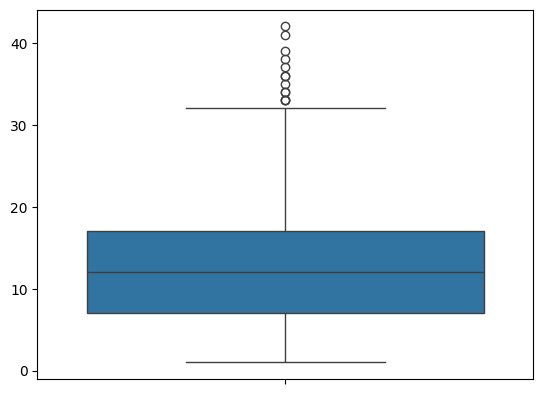

In [9]:
lens = [len(i) for i in s.clusters.values()]
sns.boxplot(lens)
plt.show()

Распределение довольно равномерное.

Посмотрим на максимальный по размеру кластер:

In [10]:
max_length = max(lens)
for c, i in [(i, len(i),) for i in s.clusters.values()]:
    if i == max_length:
        pprint(c)

('выменять_VERB',
 'прицениться_VERB',
 'расхватываться_VERB',
 'променять_VERB',
 'продаваться_VERB',
 'накупить_VERB',
 'накупать_VERB',
 'обменять_VERB',
 'перекупить_VERB',
 'раскупать_VERB',
 'выкупить_VERB',
 'скупить_VERB',
 'арендовать_VERB',
 'продать_VERB',
 'выкупать_VERB',
 'продавать_VERB',
 'докупать_VERB',
 'скупать_VERB',
 'обменивать_VERB',
 'распродать_VERB',
 'сбывать_VERB',
 'покупать_VERB',
 'перепродать_VERB',
 'скупаться_VERB',
 'заказывать_VERB',
 'продаться_VERB',
 'перепродавать_VERB',
 'выменивать_VERB',
 'покупаться_VERB',
 'расхватать_VERB',
 'приобретаться_VERB',
 'раскупить_VERB',
 'прикупать_VERB',
 'купить_VERB',
 'раскупаться_VERB',
 'перекупать_VERB',
 'прикупить_VERB',
 'расхватывать_VERB',
 'променивать_VERB',
 'торговать_VERB',
 'распродавать_VERB',
 'распродаваться_VERB')


Это кластер из глаголов, обозначающих покупку и продажу (высокая косинусная близость антонимов - известный феномен в дистрибутивной семантике, так что это ожидаемо). Как видно, он большой в основном из-за своих гипонимов - перекупить_VERB, заказывать_VERB, расхватывать_VERB.

По моим наблюдениям, абсолютное большинство кластеров имеют очевидную интерпретацию.